# Entropy Statistics Analysis (English) - n_iter=5

This notebook collects entropy values from queries to determine the entropy range for mapping purposes.

## Structure:
- **Cells 1-4**: Data collection phase - Run once to collect and save results
- **Cells 5-7**: Analysis phase - Can be run independently by loading saved CSV results

## Goals:
1. Load test queries from JSON file
2. Collect entropy values using n=5 (average over 5 API calls for better stability)
3. Save results to CSV for future analysis
4. Load saved results and perform statistics/visualization


## Cell 1: Setup and Import


In [4]:
import sys
import os
import json
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Dict

# Set matplotlib to handle fonts
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("Setup completed!")


Setup completed!


## Cell 2: Import Modules and Load Queries


In [5]:
from backend.models.adaptive_controller import AdaptiveController
from backend.config.config import get_config

# Initialize adaptive controller
config = get_config()
controller = AdaptiveController(
    k_min=config.adaptive.k_min,
    k_max=config.adaptive.k_max
)

# Load test queries from JSON
queries_file = Path("test_queries_en.json")
with open(queries_file, 'r', encoding='utf-8') as f:
    test_queries = json.load(f)

# Flatten queries into list with categories
all_queries = []
for category, queries in test_queries.items():
    for query in queries:
        all_queries.append({
            'query': query,
            'difficulty': category
        })

print(f"Loaded {len(all_queries)} queries")
print(f"  - Easy: {len([q for q in all_queries if q['difficulty'] == 'easy'])}")
print(f"  - Medium: {len([q for q in all_queries if q['difficulty'] == 'medium'])}")
print(f"  - Hard: {len([q for q in all_queries if q['difficulty'] == 'hard'])}")
print(f"\nUsing n_iterations = 5 for better averaging and stability")


Loaded 101 queries
  - Easy: 34
  - Medium: 34
  - Hard: 33

Using n_iterations = 5 for better averaging and stability


## Cell 3: Collect Entropy Data (n=5)


In [6]:
def collect_entropy_data(queries: List[Dict], language: str = "en", n_iterations: int = 5) -> pd.DataFrame:
    """
    Collect entropy values from queries.
    Using n_iterations=5 to average over multiple API calls for better stability.
    
    Returns:
        DataFrame with columns: sample_id, query, difficulty, entropy, entropy_std, n_iterations
    """
    results = []
    
    print(f"Starting entropy collection with n_iterations={n_iterations}...")
    print(f"Total queries: {len(queries)}\n")
    
    for idx, item in enumerate(queries, 1):
        query = item['query']
        difficulty = item['difficulty']
        
        print(f"[{idx}/{len(queries)}] {difficulty}: {query[:60]}...")
        
        try:
            # Run adaptive controller to get entropy
            k_determined, metadata = controller.decide(
                query=query,
                language=language,
                n=n_iterations
            )
            
            avg_entropy = metadata.get('average_entropy', 0.0)
            entropy_std = metadata.get('entropy_std', 0.0)
            
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': avg_entropy,
                'entropy_std': entropy_std,
                'k_determined': k_determined,
                'n_iterations': n_iterations
            })
            
        except Exception as e:
            print(f"    ERROR: {str(e)}")
            # Still save the record with error
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': None,
                'entropy_std': None,
                'k_determined': None,
                'n_iterations': n_iterations,
                'error': str(e)
            })
            continue
    
    return pd.DataFrame(results)

# Collect data with n=5
df_entropy = collect_entropy_data(all_queries, language="en", n_iterations=5)

print(f"\n✓ Collected {len(df_entropy)} samples")
df_entropy.head(10)


Starting entropy collection with n_iterations=5...
Total queries: 101

[1/101] easy: what is python?...
[2/101] easy: what is git?...
[3/101] easy: what is ai?...
[4/101] easy: what is machine learning?...
[5/101] easy: what is deep learning?...
[6/101] easy: what is neural network?...
[7/101] easy: what is a database?...
[8/101] easy: what is an algorithm?...
[9/101] easy: what is programming?...
[10/101] easy: what is software?...
[11/101] easy: what is java?...
[12/101] easy: what is javascript?...
[13/101] easy: what is html?...
[14/101] easy: what is css?...
[15/101] easy: what is sql?...
[16/101] easy: what is api?...
[17/101] easy: what is json?...
[18/101] easy: what is xml?...
[19/101] easy: what is http?...
[20/101] easy: what is https?...
[21/101] easy: what is tcp?...
[22/101] easy: what is ip?...
[23/101] easy: what is dns?...
[24/101] easy: what is cloud?...
[25/101] easy: what is docker?...
[26/101] easy: what is kubernetes?...
[27/101] easy: what is linux?...
[28/101] e

,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,what is python?,easy,0.262227,0.0,0,5
1,2,what is git?,easy,0.243734,0.0,0,5
2,3,what is ai?,easy,0.285295,0.0,0,5
3,4,what is machine learning?,easy,0.300221,0.0,0,5
4,5,what is deep learning?,easy,0.275353,0.0,0,5
5,6,what is neural network?,easy,0.309983,0.0,0,5
6,7,what is a database?,easy,0.351878,0.0,0,5
7,8,what is an algorithm?,easy,0.315035,0.0,0,5
8,9,what is programming?,easy,0.344993,0.0,0,5
9,10,what is software?,easy,0.348253,0.0,0,5


In [7]:
# Save results to CSV
csv_file = "entropy_analysis_results_en.csv"
df_entropy.to_csv(csv_file, index=False)
print(f"✓ Results saved to: {csv_file}")
print(f"Total samples: {len(df_entropy)}")
df_entropy.head(10)


✓ Results saved to: entropy_analysis_results_en.csv
Total samples: 101


,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,what is python?,easy,0.262227,0.0,0,5
1,2,what is git?,easy,0.243734,0.0,0,5
2,3,what is ai?,easy,0.285295,0.0,0,5
3,4,what is machine learning?,easy,0.300221,0.0,0,5
4,5,what is deep learning?,easy,0.275353,0.0,0,5
5,6,what is neural network?,easy,0.309983,0.0,0,5
6,7,what is a database?,easy,0.351878,0.0,0,5
7,8,what is an algorithm?,easy,0.315035,0.0,0,5
8,9,what is programming?,easy,0.344993,0.0,0,5
9,10,what is software?,easy,0.348253,0.0,0,5


## Cell 5: Read Result

**Note:** If you have already run the data collection (Cell 3) and saved results, you can skip Cells 1-4 and start from this cell to load the saved results.


In [8]:
# Read results from CSV file
csv_file = "entropy_analysis_results_en.csv"
df_entropy = pd.read_csv(csv_file)

print(f"✓ Loaded {len(df_entropy)} samples from {csv_file}")
print(f"\nData preview:")
df_entropy.head(10)


✓ Loaded 101 samples from entropy_analysis_results_en.csv

Data preview:


,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,what is python?,easy,0.262227,0.0,0,5
1,2,what is git?,easy,0.243734,0.0,0,5
2,3,what is ai?,easy,0.285295,0.0,0,5
3,4,what is machine learning?,easy,0.300221,0.0,0,5
4,5,what is deep learning?,easy,0.275353,0.0,0,5
5,6,what is neural network?,easy,0.309983,0.0,0,5
6,7,what is a database?,easy,0.351878,0.0,0,5
7,8,what is an algorithm?,easy,0.315035,0.0,0,5
8,9,what is programming?,easy,0.344993,0.0,0,5
9,10,what is software?,easy,0.348253,0.0,0,5


## Cell 6: Basic Statistics


In [9]:
# Filter valid samples
df_valid = df_entropy[df_entropy['entropy'].notna()]

print("=== BASIC STATISTICS (n_iter=5) ===\n")
print("Overall Statistics:")
print(df_valid['entropy'].describe())
print(f"\nRange: [{df_valid['entropy'].min():.4f}, {df_valid['entropy'].max():.4f}]")

print("\nBy Difficulty Level:")
print(df_valid.groupby('difficulty')['entropy'].describe())

print("\nEntropy Standard Deviation (across 5 iterations):")
if 'entropy_std' in df_valid.columns:
    print(df_valid['entropy_std'].describe())

print("\nPercentiles:")
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df_valid['entropy'], p)
    print(f"  {p}th percentile: {val:.4f}")


=== BASIC STATISTICS (n_iter=5) ===

Overall Statistics:
count    101.000000
mean       0.354045
std        0.068531
min        0.200318
25%        0.309983
50%        0.344993
75%        0.398360
max        0.556419
Name: entropy, dtype: float64

Range: [0.2003, 0.5564]

By Difficulty Level:
            count      mean       std       min       25%       50%       75%  \
difficulty                                                                      
easy         34.0  0.310931  0.052732  0.200318  0.276258  0.314181  0.343665   
hard         33.0  0.412556  0.064113  0.288489  0.370291  0.408531  0.439445   
medium       34.0  0.340369  0.043974  0.258069  0.305668  0.333886  0.370728   

                 max  
difficulty            
easy        0.427267  
hard        0.556419  
medium      0.430206  

Entropy Standard Deviation (across 5 iterations):
count    101.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: entropy_

## Cell 7: Scatter Plot Visualization


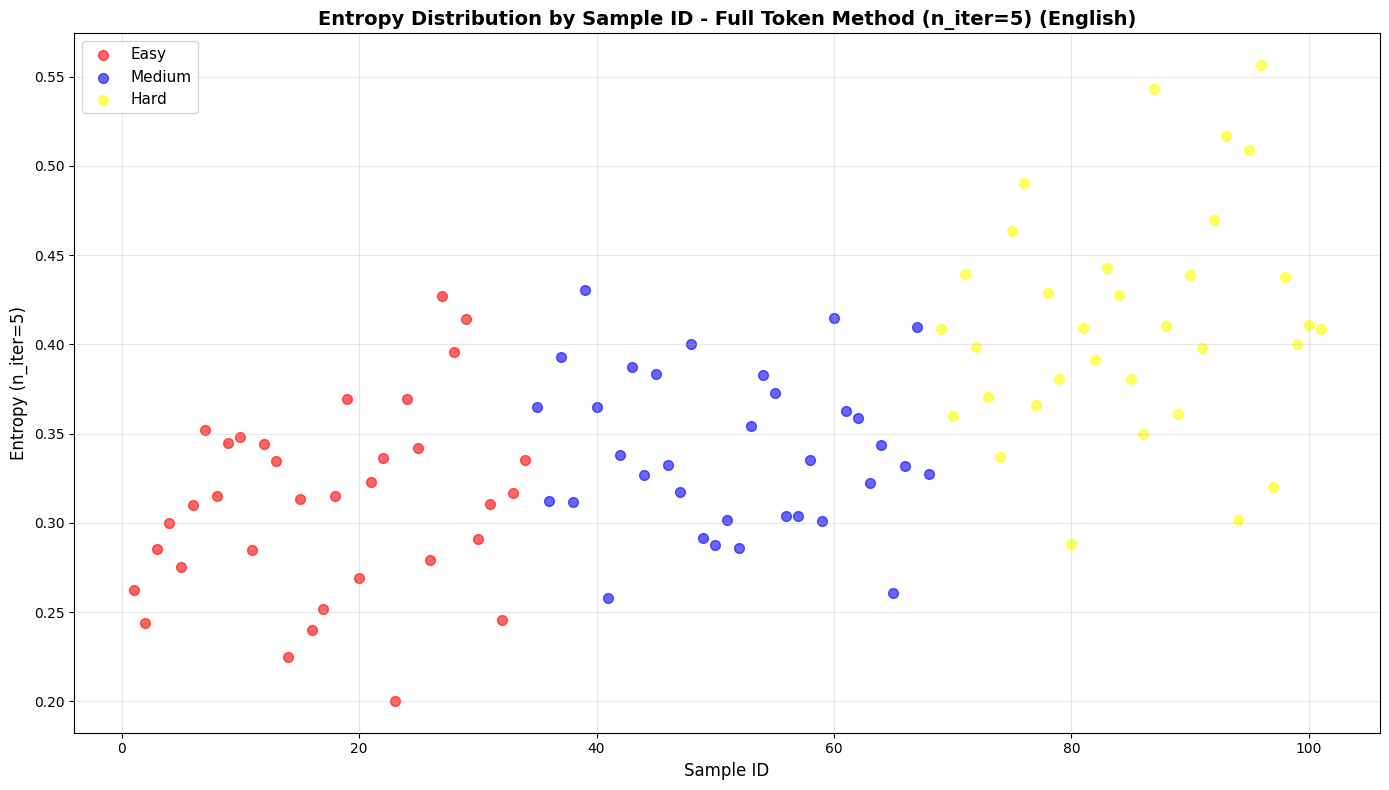

✓ Visualization completed
  - Red: Easy queries (34 samples)
  - Blue: Medium queries (34 samples)
  - Yellow: Hard queries (33 samples)


In [10]:
# Filter valid samples
df_valid = df_entropy[df_entropy['entropy'].notna()]

# Color mapping: Red (easy), Blue (medium), Yellow (hard)
color_map = {
    'easy': 'red',
    'medium': 'blue',
    'hard': 'yellow'
}

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

for difficulty in ['easy', 'medium', 'hard']:
    df_diff = df_valid[df_valid['difficulty'] == difficulty]
    if len(df_diff) > 0:
        ax.scatter(
            df_diff['sample_id'],
            df_diff['entropy'],
            c=color_map[difficulty],
            label=difficulty.capitalize(),
            alpha=0.6,
            s=50
        )

ax.set_xlabel('Sample ID', fontsize=12)
ax.set_ylabel('Entropy (n_iter=5)', fontsize=12)
ax.set_title('Entropy Distribution by Sample ID - Full Token Method (n_iter=5) (English)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization completed")
print(f"  - Red: Easy queries ({len(df_valid[df_valid['difficulty'] == 'easy'])} samples)")
print(f"  - Blue: Medium queries ({len(df_valid[df_valid['difficulty'] == 'medium'])} samples)")
print(f"  - Yellow: Hard queries ({len(df_valid[df_valid['difficulty'] == 'hard'])} samples)")
